In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def download_macro_data(url):
    print(f"Fetching macroeconomic data from:{url}")
    df = pd.read_stata(url)
    return df

In [107]:
url_macro = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta'
df_unemp_raw = download_macro_data(url_macro)
print(df_unemp_raw.columns) # Print all column names

# Three ways to print first three rows (selected, without using .head(3))
df_unemp_raw.loc[0:2,:] 
df_unemp_raw.iloc[0:3,:]
df_unemp_raw[0:3]

Fetching macroeconomic data from:https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta
Index(['ISO3', 'year', 'ADB_unemp', 'AFDB_unemp', 'AHSTAT_unemp',
       'AMECO_unemp', 'EUS_unemp', 'HFS_unemp', 'ILO_unemp', 'IMF_IFS_unemp',
       'IMF_WEO_unemp', 'JST_unemp', 'OECD_EO_unemp', 'OECD_KEI_unemp',
       'CS1_unemp', 'unemp', 'chainlinking_ratio', 'source', 'source_change'],
      dtype='str')


,ISO3,year,ADB_unemp,AFDB_unemp,AHSTAT_unemp,AMECO_unemp,EUS_unemp,HFS_unemp,ILO_unemp,IMF_IFS_unemp,IMF_WEO_unemp,JST_unemp,OECD_EO_unemp,OECD_KEI_unemp,CS1_unemp,unemp,chainlinking_ratio,source,source_change
0,ZWE,2023.0,NaN,NaN,NaN,NaN,NaN,NaN,9.348,NaN,NaN,NaN,NaN,NaN,NaN,9.348,1.0,ILO,1.0
1,ZWE,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,10.087,10.139,NaN,NaN,NaN,NaN,NaN,10.139,1.0,IMF_IFS,NaN


In [120]:
# Select only three columns from raw data (by applying double square bracket to get DataFrame Type output)
df_unemp = df_unemp_raw[['ISO3','year','unemp']]
print(df_unemp)

# Select only three columns & five rows
print(df_unemp_raw[0:5][['ISO3','year','unemp']])

# Select only country-years with unemp > 20
df_unemp_raw[df_unemp_raw.unemp > 20][['ISO3','year','unemp']]


     ISO3    year   unemp
0     ZWE  2023.0   9.348
1     ZWE  2022.0  10.139
2     ZWE  2021.0   9.540
3     ZWE  2020.0   7.373
4     ZWE  2019.0   7.373
...   ...     ...     ...
9307  ABW  1995.0   6.003
9308  ABW  1994.0   5.071
9309  ABW  1993.0   6.029
9310  ABW  1992.0   6.431
9311  ABW  1991.0   6.078

[9312 rows x 3 columns]
  ISO3    year   unemp
0  ZWE  2023.0   9.348
1  ZWE  2022.0  10.139
2  ZWE  2021.0   9.540
3  ZWE  2020.0   7.373
4  ZWE  2019.0   7.373


,ISO3,year,unemp
80,ZAF,2029.0,34.737999
81,ZAF,2028.0,34.526001
82,ZAF,2027.0,34.286999
83,ZAF,2026.0,34.115002
84,ZAF,2025.0,33.893002
...,...,...,...
9203,AIA,1984.0,26.180000
9213,AIA,1974.0,39.950001
9231,AGO,2004.0,23.643000
9256,AFG,2017.0,23.900000


In [115]:
# Decriptive statistics of raw data (transposed output)
print(df_unemp_raw.describe().T)

# Correlation matrix among selected columns by using .loc[:,:] (given only colnames of the two ends and automatically select all columns in between)
df_unemp_raw.loc[:,'ILO_unemp':'IMF_WEO_unemp'].corr()


                     count         mean        std          min          25%  \
year                9312.0  1992.614583  34.572712  1760.000000  1986.000000   
ADB_unemp            766.0     6.097886   5.360541     0.100000     3.100417   
AFDB_unemp           193.0    11.702124   7.550448     0.900000     6.440000   
AHSTAT_unemp         113.0     3.022613   2.100338     0.463037     1.075121   
AMECO_unemp         2046.0     3.242878   2.309230     0.000000     1.781488   
EUS_unemp            344.0     8.582267   3.961749     2.000000     5.975000   
HFS_unemp             12.0     2.458333   1.193511     0.800000     1.775000   
ILO_unemp           2915.0     8.328982   6.201743     0.081000     4.155000   
IMF_IFS_unemp       4550.0     7.997929   5.806575     0.039000     4.006583   
IMF_WEO_unemp       4634.0     8.703784   6.098856     0.025000     4.792000   
JST_unemp           1949.0     5.484313   4.081174     0.035923     2.300000   
OECD_EO_unemp       1994.0     6.944284 

,ILO_unemp,IMF_IFS_unemp,IMF_WEO_unemp
ILO_unemp,1.000000,0.982944,0.948812
IMF_IFS_unemp,0.982944,1.000000,0.932544
IMF_WEO_unemp,0.948812,0.932544,1.000000


In [72]:
obj = pd.Series(['red','green','blue'], index = [0,2,4])
obj_new = obj.reindex(range(6), method="ffill")
obj_new.drop([1,2,3], inplace=False)
obj_new[obj_new.isin(['green','red'])]

0      red
1      red
2    green
3    green
dtype: str

In [133]:
# Filter out data of Zimbabwe
df_unemp_zimbabwe = df_unemp.query("ISO3 == 'ZWE'")
df_unemp_zimbabwe = df_unemp[df_unemp.ISO3 == 'ZWE']
df_unemp_zimbabwe.head(5)

,ISO3,year,unemp
0,ZWE,2023.0,9.348
1,ZWE,2022.0,10.139
2,ZWE,2021.0,9.540
3,ZWE,2020.0,7.373
4,ZWE,2019.0,7.373


In [134]:
df_unemp_zimbabwe = df_unemp_zimbabwe.drop('ISO3', axis='columns') # IMPORTANT: axis = 'columns'. Or by default is searching row indexes.
print(df_unemp_zimbabwe)

      year   unemp
0   2023.0   9.348
1   2022.0  10.139
2   2021.0   9.540
3   2020.0   7.373
4   2019.0   7.373
5   2018.0     NaN
6   2017.0     NaN
7   2016.0     NaN
8   2015.0     NaN
9   2014.0   4.774
10  2013.0     NaN
11  2012.0     NaN
12  2011.0   5.368
13  2010.0     NaN
14  2009.0     NaN
15  2008.0     NaN
16  2007.0     NaN
17  2006.0     NaN
18  2005.0     NaN
19  2004.0   4.390
20  2003.0     NaN
21  2002.0     NaN
22  2001.0     NaN
23  2000.0     NaN
24  1999.0   6.000
25  1998.0     NaN
26  1997.0   6.930
27  1996.0     NaN
28  1995.0     NaN
29  1994.0   4.960
30  1993.0     NaN
31  1992.0     NaN
32  1991.0     NaN
33  1990.0     NaN
34  1989.0     NaN
35  1988.0     NaN
36  1987.0   7.180
37  1986.0     NaN
38  1985.0     NaN
39  1984.0     NaN
40  1983.0     NaN
41  1982.0  10.800


In [214]:
# Three operations: (1) Set "year" column as index column. (2) Drop entries where unemp are NA. (3) Sort the entries by index.
df_unemp_zimbabwe = df_unemp_zimbabwe.set_index("year").dropna().sort_index()
df_unemp_zimbabwe

,unemp
year,
1982.0,10.800
1987.0,7.180
1994.0,4.960
1997.0,6.930
1999.0,6.000
2004.0,4.390
2011.0,5.368
2014.0,4.774
2019.0,7.373


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,
         0.,  1.,  0.,  1.,  2.,  1.,  0.,  0.,  3.,  2.,  3.,  4.,  1.,
         6.,  4.,  4.,  8.,  7., 11.,  7.,  7.,  6., 15., 13., 10., 13.,
        21., 13., 17., 15., 18., 25., 20., 15., 21., 24., 27., 23., 16.,
        34., 28., 21., 33., 25., 24., 21., 26., 20., 19., 28., 17., 33.,
        29., 19., 22., 14., 11., 14., 15., 14., 12., 14., 14.,  8., 15.,
         8., 10.,  9.,  3.,  5.,  8.,  3.,  5.,  3.,  2.,  2.,  6.,  5.,
         3.,  5.,  1.,  0.,  1.,  2.,  0.,  0.,  1.]),
 array([-3.72209401, -3.65620305, -3.59031209, -3.52442114, -3.45853018,
        -3.39263922, -3.32674826, -3.2608573 , -3.19496634, -3.12907539,
        -3.06318443, -2.99729347, -2.93140251, -2.86551155, -2.79962059,
        -2.73372963, -2.66783868, -2.60194772, -2.53605676, -2.4701658 ,
        -2.40427484, -2.33838388, -2.27249292, -2.20660197, -2.14071101,
        -2.07482005, -2.00892909, -1.94303813, -1.87714717, -1.811256

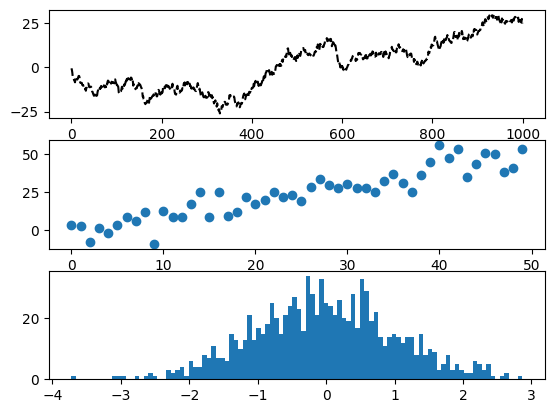

In [211]:
# Using matplotlib.pyplot to make graphs
fig = plt.figure() # Create a blank canvas

ax1 = fig.add_subplot(3,1,1) # Create a subplot on the canvas
ax2 = fig.add_subplot(3,1,2)
ax3 = fig.add_subplot(3,1,3)

ax1.plot(np.random.randn(1000).cumsum(),'k--')
ax2.scatter(np.arange(50), np.arange(50) + 7*np.random.randn(50))
ax3.hist(np.random.randn(1000), bins=100)

pandas.Series

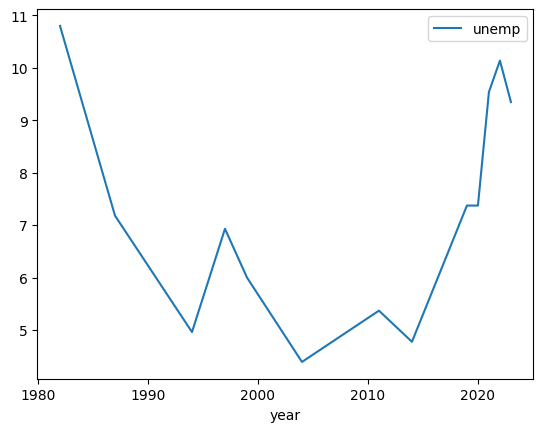

In [218]:
df_unemp_zimbabwe.plot()

,unemp
mean,7.686186
std,6.259881
min,0.000000
25%,3.475000
50%,6.058000
75%,9.800000
max,70.000000


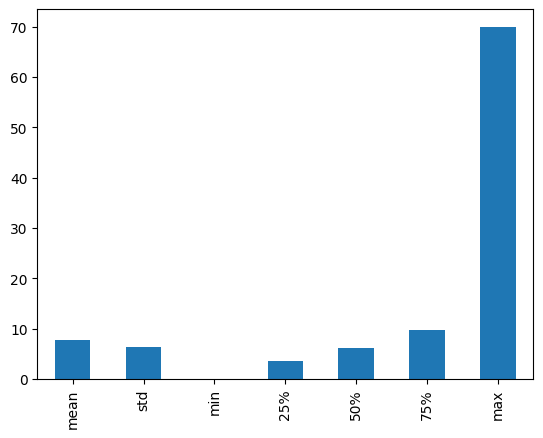

In [226]:
df_unemp['unemp'].describe().drop(['count'],axis=0).plot(kind='bar')
df_unemp['unemp'].describe().drop(['count'],axis=0).to_frame()

In [233]:
df_unemp_descriptive_bycountry = df_unemp.groupby('ISO3')['unemp'].describe()
df_unemp_descriptive_bycountry.head(5)

,count,mean,std,min,25%,50%,75%,max
ISO3,,,,,,,,
ABW,39.0,7.088641,1.902090,3.250,6.05350,6.900000,8.700000,11.400000
AFG,13.0,8.300230,7.950102,1.692,3.37019,3.370460,8.229080,23.900000
AGO,11.0,14.545181,5.317847,3.782,11.88950,15.799000,16.633499,23.643000
AIA,6.0,16.000000,13.928809,6.560,7.38750,8.030001,21.700001,39.950001
ALB,50.0,12.198080,4.889706,2.813,10.70000,12.600000,14.975000,26.500000


In [250]:
df_plot = df_unemp_descriptive_bycountry['mean'].head(10).sort_values()
df_plot

ISO3
ARE     2.413231
AND     2.833750
ABW     7.088641
AFG     8.300230
ARG     8.671018
ALB    12.198080
ANT    13.545453
AGO    14.545181
AIA    16.000000
ARM    17.224005
Name: mean, dtype: float64

Text(0.5, 1.0, 'Mean unemployment by country over sample')

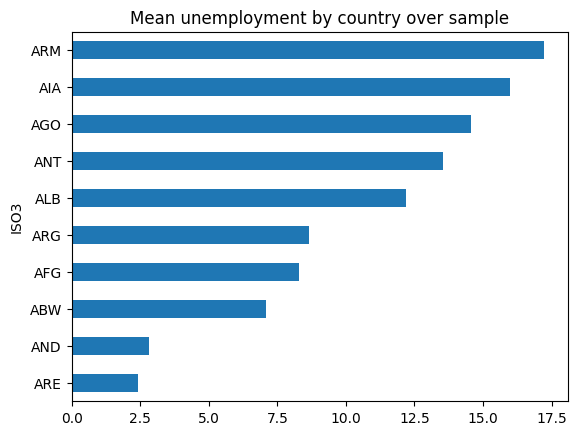

In [251]:
df_plot.plot(kind = 'barh')
import matplotlib.pyplot as plt
plt.title("Mean unemployment by country over sample")

<Axes: xlabel='ISO3'>

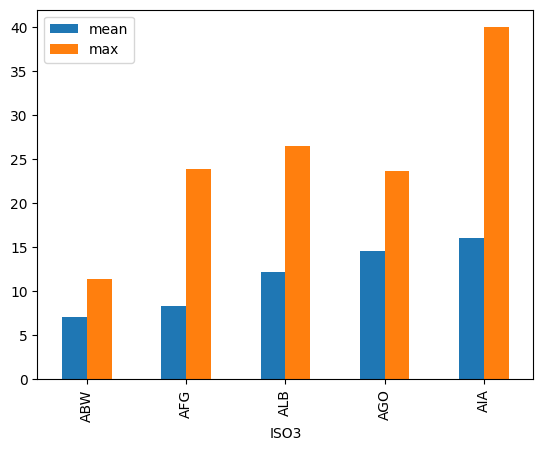

In [258]:
df_unemp_descriptive_bycountry[['mean','max']].head(5).sort_values(by='mean').plot(kind='bar')

In [262]:
country_code = pd.read_html('https://www.iban.com/country-codes')[0]
country_code

,Country,Alpha-2 code,Alpha-3 code,Numeric
0,Afghanistan,AF,AFG,4
1,Åland Islands,AX,ALA,248
2,Albania,AL,ALB,8
3,Algeria,DZ,DZA,12
4,American Samoa,AS,ASM,16
...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876
245,Western Sahara,EH,ESH,732
246,Yemen,YE,YEM,887
247,Zambia,ZM,ZMB,894


In [292]:
# .to_numpy OR .value transform Dataframe to ndarray discarding indexes and colnames
country_map = dict(country_code[['Alpha-3 code', 'Country']].to_numpy())
country_map

{'AFG': 'Afghanistan',
 'ALA': 'Åland Islands',
 'ALB': 'Albania',
 'DZA': 'Algeria',
 'ASM': 'American Samoa',
 'AND': 'Andorra',
 'AGO': 'Angola',
 'AIA': 'Anguilla',
 'ATA': 'Antarctica',
 'ATG': 'Antigua and Barbuda',
 'ARG': 'Argentina',
 'ARM': 'Armenia',
 'ABW': 'Aruba',
 'AUS': 'Australia',
 'AUT': 'Austria',
 'AZE': 'Azerbaijan',
 'BHS': 'Bahamas (the)',
 'BHR': 'Bahrain',
 'BGD': 'Bangladesh',
 'BRB': 'Barbados',
 'BLR': 'Belarus',
 'BEL': 'Belgium',
 'BLZ': 'Belize',
 'BEN': 'Benin',
 'BMU': 'Bermuda',
 'BTN': 'Bhutan',
 'BOL': 'Bolivia (Plurinational State of)',
 'BES': 'Bonaire, Sint Eustatius and Saba',
 'BIH': 'Bosnia and Herzegovina',
 'BWA': 'Botswana',
 'BVT': 'Bouvet Island',
 'BRA': 'Brazil',
 'IOT': 'British Indian Ocean Territory (the)',
 'BRN': 'Brunei Darussalam',
 'BGR': 'Bulgaria',
 'BFA': 'Burkina Faso',
 'BDI': 'Burundi',
 'CPV': 'Cabo Verde',
 'KHM': 'Cambodia',
 'CMR': 'Cameroon',
 'CAN': 'Canada',
 'CYM': 'Cayman Islands (the)',
 'CAF': 'Central African R

In [311]:
# Rename passes on a dictionary mapping old names (key) to new names(value)
df_unemp_descriptive_bycountry['max'].rename(country_map).sort_values() # Output a Series with new indexes

# By applying .rename to a Dataframe, user should clarify through parameter "index=..." or "column=..." which indexes are to be renamed.
# By applying .sort_values to a Dataframe, user should clarify which column to be the reference for sorting (through parameter "by=...")
df_plot = df_unemp_descriptive_bycountry[['max']].rename(index = country_map).sort_values(by='max') # Output a Dataframe with new indexes
# Turning Index column to ordinary column
#df_plot = df_plot.reset_index() 

df_plot

,max
ISO3,
Qatar,1.480000
Benin,2.647000
Liechtenstein,2.660000
Kuwait,2.900000
Guinea-Bissau,3.127000
...,...
Armenia,38.400002
Anguilla,39.950001
Kiribati,40.895641


In [336]:
df_plot.query("ISO3 in ['France', 'Japan', 'China', 'Greece']")
# IMPORTANT: 
# (1) Index column can only be referred to through .index rather than colname. 
# (2) .isin only accepts list-like objects (so str is not valid, even for lists with single element).
df_plot = df_plot[df_plot.index.isin(['France', 'Japan', 'China', 'Greece'])]
df_plot

,max
ISO3,
China,5.617
Japan,6.800
France,15.400
Greece,27.475


Text(0.5, 1.0, 'Max Unemployment by Country in Sample')

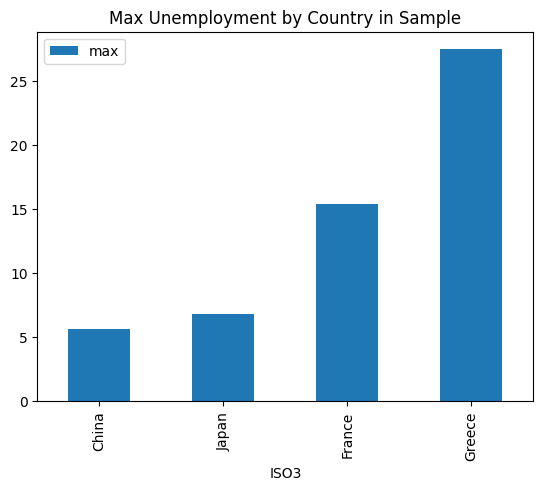

In [338]:
df_plot.plot(kind='bar')
plt.title("Max Unemployment by Country in Sample")

In [355]:
df_unemp_datetime = df_unemp.copy() # Make a copy of df_unemp
df_unemp_datetime.year = pd.to_datetime(df_unemp_datetime.year, format="%Y")
df_unemp_datetime

,ISO3,year,unemp
0,ZWE,2023-01-01,9.348
1,ZWE,2022-01-01,10.139
2,ZWE,2021-01-01,9.540
3,ZWE,2020-01-01,7.373
4,ZWE,2019-01-01,7.373
...,...,...,...
9307,ABW,1995-01-01,6.003
9308,ABW,1994-01-01,5.071
9309,ABW,1993-01-01,6.029
9310,ABW,1992-01-01,6.431


<Axes: xlabel='year'>

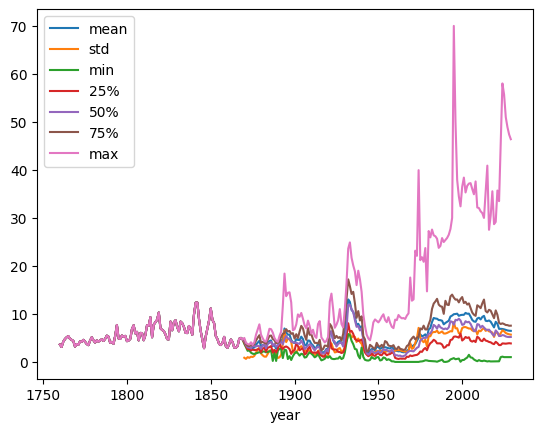

In [376]:
df_unemp.groupby('year')['unemp'].describe().drop(['count'], axis=1).plot()

<Axes: xlabel='year'>

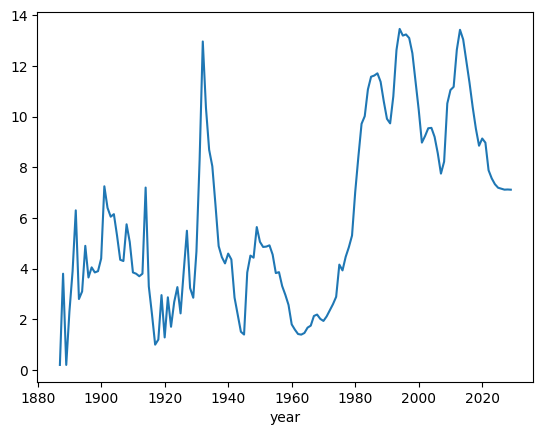

In [386]:
df_unemp[df_unemp.ISO3.isin(['FRA','DEU','ESP','ITA'])].groupby('year')['unemp'].mean().plot()